In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Input, Model, layers
from tensorflow.keras.layers import Dense, Concatenate
from tensorflow.keras.regularizers import Regularizer
from tensorflow.keras import regularizers
import scipy.stats as ss
from scipy.linalg import null_space
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

/Users/alamson/local/miniconda/envs/elektrum/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/Users/alamson/local/miniconda/envs/elektrum/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/Users/alamson/local/miniconda/envs/elektrum/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/Users/alamson/l

In [2]:
# Load the data from csv files
df = pd.read_csv("../test_files/test_4ring_var_rates/test_4ring.csv")
ka_mat = np.loadtxt("../test_files/test_4ring_var_rates/test_4ring_ka_mat.nptxt")
ka_contrib = np.loadtxt("../test_files/test_4ring_var_rates/test_4ring_rate_contrib_mat.nptxt")
x = df["seq"].values
y = df["raw_activity"].values

enc = OneHotEncoder(categories=[["A", "B"]], sparse=False)

# Encode sequences as one-hot vectors
n_samples = len(x)
seq_length = len(x[0])  # Assuming all sequences have the same length
flat = np.array([list(seq) for seq in x]).flatten()[:, None]
encoded = enc.fit_transform(flat)
x = encoded.reshape(n_samples, seq_length, 2)  # shape: (n_samples, seq_length, 2)
print(ka_mat)

[[0. 1. 0. 1. 0. 0. 1.]
 [0. 1. 0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0. 1. 0.]
 [1. 0. 0. 1. 0. 0. 1.]
 [1. 0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 1. 0.]
 [1. 0. 1. 0. 1. 0. 0.]]


In [3]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=777
)

In [43]:
# No regularizations
inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=1000, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 80 samples, validate on 20 samples
Epoch 1/1000
80/80 [==============================] - 1s 7ms/sample - loss: 0.0130 - val_loss: 0.0079
Epoch 2/1000
80/80 [==============================] - 0s 84us/sample - loss: 0.0123 - val_loss: 0.0074
Epoch 3/1000
80/80 [==============================] - 0s 89us/sample - loss: 0.0115 - val_loss: 0.0069
Epoch 4/1000
80/80 [==============================] - 0s 81us/sample - loss: 0.0108 - val_loss: 0.0066
Epoch 5/1000
80/80 [==============================] - 0s 80us/sample - loss: 0.0102 - val_loss: 0.0062
Epoch 6/1000
80/80 [==============================] - 0s 79us/sample - loss: 0.0097 - val_loss: 0.0060
Epoch 7/1000
80/80 [==============================] - 0s 80us/sample - loss: 0.0091 - val_loss: 0.0057
Epoch 8/1000
80/80 [==============================] - 0s 77us/sample - loss: 0.0087 - val_loss: 0.0056
Epoch 9/1000
80/80 [==============================] - 0s 78us/sample - loss: 0.0082 - val_loss: 0.0054
Epoch 10/1000


Exp Biases: [1.094303  1.0272013 1.0369359 1.1146199 1.0793976 1.007405  1.0777233]
Weights:
 [[-0.2076474   0.23449156  0.5008424  -0.3008232   0.37435526 -0.15967321 -0.18485786]
 [ 0.19917189 -0.15641393 -0.31871927  0.2988283   0.39394695 -0.02418497  0.693704  ]
 [ 0.5358663  -0.23284948  0.20981674  0.3564644  -0.2294407   0.24434315  0.194604  ]
 [ 0.65849805  0.19552785 -0.33935702  0.15377516 -0.0055008  -0.07750152 -0.14510317]
 [ 0.45292366  0.3215499   0.37789837  0.1830164   0.15112433  0.61170745  0.5999136 ]
 [-0.36548972  0.3673648  -0.13891298  0.45430592  0.24336804 -0.88637066 -0.6149939 ]
 [-0.10525167 -0.34418622 -0.28565803  0.43379185  0.22702295 -0.03663099  0.4372904 ]
 [-0.0140679   0.9549649  -0.22078514  0.6338352  -0.16219053 -0.2354835  -0.48938388]
 [-0.09324168 -0.30586493  0.01093197  0.12925349  0.19264989  0.01479938 -0.12928663]
 [-0.53949714  0.56971586  0.21639518  0.57878006  0.01359607  0.6153691  -0.28522658]
 [ 0.02524196  0.25731805 -0.0598191

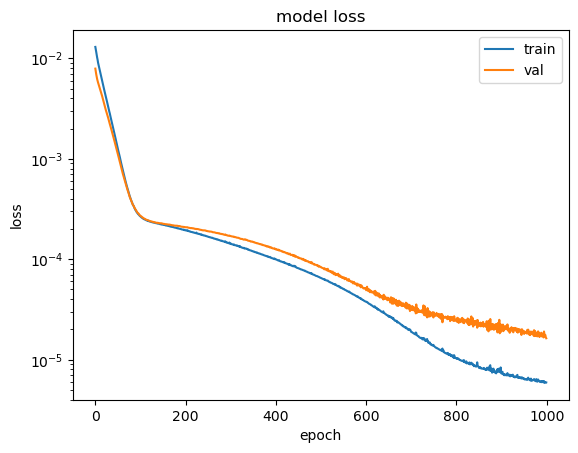

In [44]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [4]:
# With log cost function
inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation=None, name="log_rates", 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)

def mse_log_space(y_true, y_pred):
    """MSE loss in log space"""
    # epsilon = 1e-9
    epsilon = 0
    return tf.keras.losses.mean_squared_error(
        tf.math.log(y_true + epsilon), 
        tf.math.log(y_pred + epsilon)
    )

model.compile(optimizer="adam", loss=mse_log_space)

# Train the model
hist = model.fit(
    x_train, y_train, epochs=2000, batch_size=16, validation_data=(x_test, y_test)
)


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


(10, 7)
(7, 10)
Train on 160 samples, validate on 40 samples
Epoch 1/2000
160/160 [==============================] - 0s 796us/sample - loss: 3.7038 - val_loss: 3.3756
Epoch 2/2000
160/160 [==============================] - 0s 63us/sample - loss: 3.4984 - val_loss: 3.2067
Epoch 3/2000
160/160 [==============================] - 0s 61us/sample - loss: 3.3181 - val_loss: 3.0414
Epoch 4/2000
160/160 [==============================] - 0s 61us/sample - loss: 3.1229 - val_loss: 2.8874
Epoch 5/2000
160/160 [==============================] - 0s 59us/sample - loss: 2.9482 - val_loss: 2.7347
Epoch 6/2000
160/160 [==============================] - 0s 63us/sample - loss: 2.7802 - val_loss: 2.5829
Epoch 7/2000
160/160 [==============================] - 0s 59us/sample - loss: 2.6012 - val_loss: 2.4415
Epoch 8/2000
 16/160 [==>...........................] - ETA: 0s - loss: 3.0701

2025-07-30 13:35:03.298925: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 FMA


160/160 [==============================] - 0s 61us/sample - loss: 2.4441 - val_loss: 2.3054
Epoch 9/2000
160/160 [==============================] - 0s 58us/sample - loss: 2.2855 - val_loss: 2.1739
Epoch 10/2000
160/160 [==============================] - 0s 59us/sample - loss: 2.1473 - val_loss: 2.0453
Epoch 11/2000
160/160 [==============================] - 0s 58us/sample - loss: 2.0014 - val_loss: 1.9257
Epoch 12/2000
160/160 [==============================] - 0s 60us/sample - loss: 1.8743 - val_loss: 1.8078
Epoch 13/2000
160/160 [==============================] - 0s 57us/sample - loss: 1.7464 - val_loss: 1.6995
Epoch 14/2000
160/160 [==============================] - 0s 54us/sample - loss: 1.6276 - val_loss: 1.5957
Epoch 15/2000
160/160 [==============================] - 0s 57us/sample - loss: 1.5240 - val_loss: 1.4969
Epoch 16/2000
160/160 [==============================] - 0s 57us/sample - loss: 1.4154 - val_loss: 1.3995
Epoch 17/2000
160/160 [==============================] - 0s 5

Exp Biases: [1.0673395 1.0274193 0.9720518 1.1751478 0.8900433 0.9276634 1.2383326]
[ 0.00930986  0.00386431 -0.00404945  0.02305626 -0.01664073 -0.01072662  0.03053798]
Weights:
 [[0.9074915  0.8003999  0.5607514  0.9632494  0.9622727  1.1763619  2.0644717 ]
 [1.0246756  1.3310021  1.0815899  1.1757951  0.5242283  0.49293792 0.797515  ]
 [0.8690296  0.63585085 0.9875306  1.0248681  0.8374623  1.4182194  0.9186455 ]
 [0.76955366 0.822933   1.7248458  1.4049195  0.5657733  1.1459029  0.6447256 ]
 [1.3829321  0.79810953 1.2494901  1.3869816  1.3664583  1.2230273  1.3474463 ]
 [0.88199383 1.2320324  0.95725965 0.8161466  0.58173645 1.5466732  1.2383066 ]
 [1.2171263  0.65996706 1.0583706  0.94072926 0.6614548  0.6989907  1.3046396 ]
 [0.8754438  2.1697884  0.50652844 1.3035603  0.70180583 1.141289   1.0102855 ]
 [0.8020443  1.8299083  1.7117412  0.70545805 0.84901375 1.0155233  1.7962396 ]
 [0.59661585 1.2004591  0.42011675 0.81964314 0.6016918  0.75739634 0.98104686]
 [0.7504409  0.73444

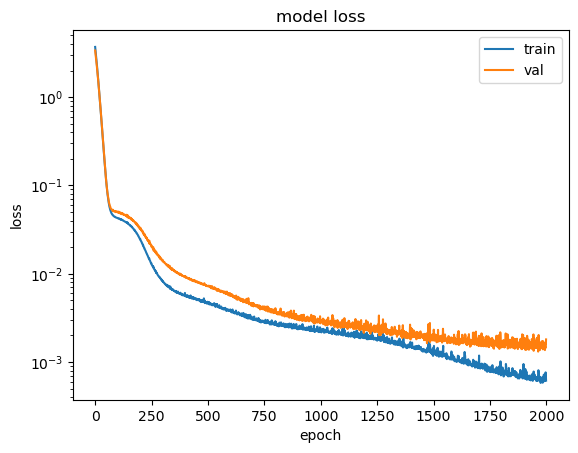

In [5]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
# weights = np.array(weights)
print(biases/weights.shape[1])
weights = np.exp(weights + biases/weights.shape[1])
print("Weights:\n", weights)
print("KA matrix:\n", ka_mat)
print("Contrib KA matrix:\n", ka_contrib)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [6]:
# With log cost function
inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation=None, name="log_rates", 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)

def mse_log_space(y_true, y_pred):
    """MSE loss in log space"""
    # epsilon = 1e-9
    epsilon = 0
    return tf.keras.losses.mean_absolute_error(
        tf.math.log(y_true + epsilon), 
        tf.math.log(y_pred + epsilon)
    )

model.compile(optimizer="adam", loss=mse_log_space)

# Train the model
hist = model.fit(
    x_train, y_train, epochs=2000, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 160 samples, validate on 40 samples
Epoch 1/2000
160/160 [==============================] - 0s 853us/sample - loss: 1.8370 - val_loss: 1.6901
Epoch 2/2000
160/160 [==============================] - 0s 64us/sample - loss: 1.6843 - val_loss: 1.5547
Epoch 3/2000
160/160 [==============================] - 0s 60us/sample - loss: 1.5439 - val_loss: 1.4194
Epoch 4/2000
160/160 [==============================] - 0s 61us/sample - loss: 1.4173 - val_loss: 1.2985
Epoch 5/2000
160/160 [==============================] - 0s 61us/sample - loss: 1.3149 - val_loss: 1.1863
Epoch 6/2000
160/160 [==============================] - 0s 62us/sample - loss: 1.2194 - val_loss: 1.1122
Epoch 7/2000
160/160 [==============================] - 0s 62us/sample - loss: 1.1488 - val_loss: 1.0542
Epoch 8/2000
160/160 [==============================] - 0s 64us/sample - loss: 1.0926 - val_loss: 1.0067
Epoch 9/2000
160/160 [==============================] - 0s 61us/sample - loss: 1.0425 - val_loss: 

Exp Biases: [0.9497741 1.1251725 0.9452556 1.2152308 0.9561817 1.0817249 0.8963742]
[-0.00736158  0.01684806 -0.00804284  0.02784773 -0.00640104  0.0112224  -0.01562818]
Weights:
 [[1.2839489  1.7856292  1.1711379  1.7838533  1.4255246  0.7540964  1.0909736 ]
 [0.75790745 1.1709467  1.1505368  0.96418494 0.69937754 0.8343365  0.8714056 ]
 [0.9948534  0.99188066 0.5899536  1.1453042  1.6241611  1.0185679  0.6123642 ]
 [0.963274   1.0984927  0.5574899  0.704554   1.0128765  1.3364518  0.53646535]
 [0.7311951  1.0324349  1.4129592  2.1621454  1.3268272  0.9184759  1.3056417 ]
 [0.9785824  1.4978192  0.96831316 1.2258663  0.6843419  1.1211454  0.515879  ]
 [1.0316921  0.86766815 1.9725385  1.1126064  1.1263021  0.50469023 1.0596222 ]
 [1.1360627  1.0812618  0.8487844  1.3083402  0.9236879  1.5644959  0.95386994]
 [1.0270196  0.77506804 1.6732033  0.89562887 1.245336   0.88195777 0.72397196]
 [1.3725445  0.8456377  0.562284   1.3446457  0.6414571  1.4216721  1.3557746 ]
 [1.831653   0.51946

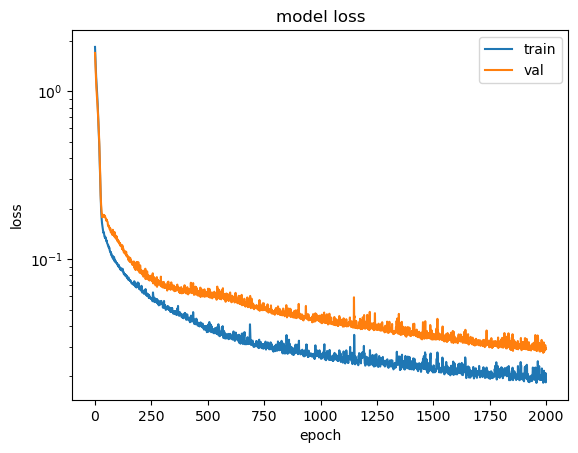

In [7]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
# weights = np.array(weights)
print(biases/weights.shape[1])
weights = np.exp(weights + biases/weights.shape[1])
print("Weights:\n", weights)
print("KA matrix:\n", ka_mat)
print("Contrib KA matrix:\n", ka_contrib)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [47]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateRegularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        # Here x is the ACTIVATION output of the layer
        # Example: L1 norm on activations
        return self.coeff * tf.log(tf.reduce_sum(tf.exp(x)))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", kernel_regularizer=LogRateRegularize(1e-7))(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)

def mse_log_space(y_true, y_pred):
    """MSE loss in log space"""
    epsilon = 1e-9
    return tf.keras.losses.mean_squared_error(
        tf.math.log(y_true + epsilon), 
        tf.math.log(y_pred + epsilon)
    )

model.compile(optimizer="adam", loss=mse_log_space)

# Train the model
hist = model.fit(
    x_train, y_train, epochs=1000, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 80 samples, validate on 20 samples
Epoch 1/1000
80/80 [==============================] - 1s 9ms/sample - loss: 1.4318 - val_loss: 1.5062
Epoch 2/1000
80/80 [==============================] - 0s 94us/sample - loss: 1.2145 - val_loss: 1.2862
Epoch 3/1000
80/80 [==============================] - 0s 84us/sample - loss: 1.0267 - val_loss: 1.1055
Epoch 4/1000
80/80 [==============================] - 0s 84us/sample - loss: 0.8724 - val_loss: 0.9600
Epoch 5/1000
80/80 [==============================] - 0s 100us/sample - loss: 0.7578 - val_loss: 0.8404
Epoch 6/1000
80/80 [==============================] - 0s 98us/sample - loss: 0.6621 - val_loss: 0.7453
Epoch 7/1000
80/80 [==============================] - 0s 81us/sample - loss: 0.5908 - val_loss: 0.6685
Epoch 8/1000
80/80 [==============================] - 0s 88us/sample - loss: 0.5331 - val_loss: 0.6076
Epoch 9/1000
80/80 [==============================] - 0s 87us/sample - loss: 0.4898 - val_loss: 0.5584
Epoch 10/1000

80/80 [==============================] - 0s 831us/sample - loss: 0.0012 - val_loss: 9.0045e-04
Epoch 882/1000
80/80 [==============================] - 0s 227us/sample - loss: 0.0011 - val_loss: 9.2523e-04
Epoch 883/1000
80/80 [==============================] - 0s 85us/sample - loss: 0.0011 - val_loss: 8.9422e-04
Epoch 884/1000
80/80 [==============================] - 0s 93us/sample - loss: 0.0011 - val_loss: 9.6704e-04
Epoch 885/1000
80/80 [==============================] - 0s 118us/sample - loss: 0.0011 - val_loss: 8.4949e-04
Epoch 886/1000
80/80 [==============================] - 0s 91us/sample - loss: 0.0011 - val_loss: 8.8936e-04
Epoch 887/1000
80/80 [==============================] - 0s 85us/sample - loss: 0.0011 - val_loss: 9.6071e-04
Epoch 888/1000
80/80 [==============================] - 0s 84us/sample - loss: 0.0011 - val_loss: 8.3747e-04
Epoch 889/1000
80/80 [==============================] - 0s 94us/sample - loss: 0.0011 - val_loss: 8.2680e-04
Epoch 890/1000
80/80 [=========

Exp Biases: [1.0376902  1.090238   0.97698563 0.9571567  1.1617452  1.0178729  1.1793369 ]
Weights:
 [[ 0.11211228  0.48092604  0.39321354 -0.00595603 -0.17048262 -0.41500902  0.25857252]
 [-0.39100692  0.35858652 -0.10045462 -0.53277755 -0.27624974 -0.3218998   0.15640089]
 [ 0.19347914 -0.34736174  0.2112995   0.4479969  -0.11104162  0.10683446 -0.20813131]
 [ 0.29495388  0.02288447 -0.13980237 -0.01639642 -0.3989105   0.12010204 -0.048344  ]
 [ 0.1280359  -0.25364083  0.28119525 -0.09190788 -0.31177634 -0.3614908  -0.0493162 ]
 [-0.13155043  0.47460034 -0.39586028 -0.10301735 -0.46687284  0.01320175 -0.00351146]
 [ 0.27274814  0.12459999  0.02258133 -0.573397   -0.05985615 -0.47304744 -0.07642108]
 [-0.3129814  -0.01968681 -0.18424094  0.3779772  -0.6097074  -0.09958107 -0.2691755 ]
 [ 0.28549913  0.14713241  0.28073943 -0.58666855  0.66108185 -0.24226926 -0.11974959]
 [ 0.23782803 -0.36942303 -0.5129584   0.12470052  0.18817477  0.31895012 -0.29894084]
 [-0.3416526  -0.293661   -0.

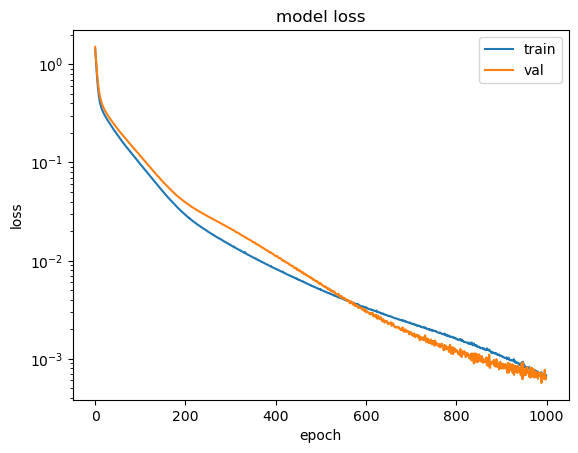

In [48]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [49]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateL1Regularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        return self.coeff * tf.log(tf.reduce_mean(tf.exp(x)))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=LogRateL1Regularize(1e-6), 
    bias_regularizer=LogRateL1Regularize(1e-6), 
    # activity_regularizer=LogRateL1Regularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


def mse_log_space(y_true, y_pred):
    """MSE loss in log space"""
    epsilon = 1e-9
    return tf.keras.losses.mean_squared_error(
        tf.math.log(y_true + epsilon), 
        tf.math.log(y_pred + epsilon)
    )

model.compile(optimizer="adam", loss=mse_log_space)

# Train the model
hist = model.fit(
    x_train, y_train, epochs=4000, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 80 samples, validate on 20 samples
Epoch 1/4000
80/80 [==============================] - 1s 9ms/sample - loss: 1.5064 - val_loss: 1.5977
Epoch 2/4000
80/80 [==============================] - 0s 89us/sample - loss: 1.2850 - val_loss: 1.3464
Epoch 3/4000
80/80 [==============================] - 0s 80us/sample - loss: 1.1167 - val_loss: 1.1392
Epoch 4/4000
80/80 [==============================] - 0s 82us/sample - loss: 0.9877 - val_loss: 0.9690
Epoch 5/4000
80/80 [==============================] - 0s 83us/sample - loss: 0.8685 - val_loss: 0.8390
Epoch 6/4000
80/80 [==============================] - 0s 76us/sample - loss: 0.7814 - val_loss: 0.7393
Epoch 7/4000
80/80 [==============================] - 0s 76us/sample - loss: 0.7131 - val_loss: 0.6632
Epoch 8/4000
80/80 [==============================] - 0s 80us/sample - loss: 0.6656 - val_loss: 0.6025
Epoch 9/4000
80/80 [==============================] - 0s 80us/sample - loss: 0.6283 - val_loss: 0.5538
Epoch 10/4000


Exp Biases: [0.9058442  1.0654131  1.00329    0.94150484 1.21807    0.9653145  1.0492735 ]
Weights:
 [[ 0.36615637  0.37807208 -0.11548341  0.19440562  0.38460773 -0.2961778   0.13867809]
 [-0.38831702  0.2742993   0.1898395   0.17383192 -0.20627527 -1.2349743   0.16113816]
 [-0.29899275 -0.2267575   0.19914111  0.17626272  0.06760967  0.4694031   0.24403714]
 [-0.5302206   0.15989086  0.33356413  0.29455864 -0.0575234  -0.04434907  0.09703616]
 [ 0.49514464 -0.18798505  0.09971979  0.39359006  0.00468404  0.1574395   0.24439862]
 [-0.00601334  0.571225   -0.6037767  -0.12669727  0.13171114 -0.05986771 -0.23121434]
 [-0.33387774 -0.0046209   0.37880298 -0.14890131  0.20199107 -0.10663519  0.06950182]
 [ 0.1370767   0.949704   -0.49016187  0.2435775  -0.2907767   0.30252784  0.4073266 ]
 [ 0.2729783   0.08663952  0.43446594 -0.52076155 -0.0925853   0.34465164 -0.33401677]
 [ 0.45537278 -0.29706004 -0.8080029   0.6494695  -0.09217382  0.17886145 -0.6699636 ]
 [-0.35847497  0.06102553  0.

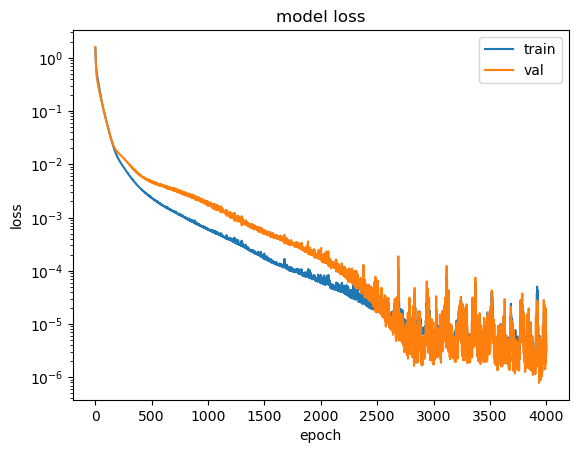

In [50]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [51]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateL1Regularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        return self.coeff * tf.log(tf.reduce_mean(tf.exp(x)))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=LogRateL1Regularize(1e-6), 
    bias_regularizer=LogRateL1Regularize(1e-6), 
    # activity_regularizer=LogRateL1Regularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=1000, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 80 samples, validate on 20 samples
Epoch 1/1000
80/80 [==============================] - 1s 11ms/sample - loss: 0.0111 - val_loss: 0.0084
Epoch 2/1000
80/80 [==============================] - 0s 90us/sample - loss: 0.0106 - val_loss: 0.0078
Epoch 3/1000
80/80 [==============================] - 0s 86us/sample - loss: 0.0099 - val_loss: 0.0073
Epoch 4/1000
80/80 [==============================] - 0s 83us/sample - loss: 0.0094 - val_loss: 0.0068
Epoch 5/1000
80/80 [==============================] - 0s 84us/sample - loss: 0.0089 - val_loss: 0.0064
Epoch 6/1000
80/80 [==============================] - 0s 78us/sample - loss: 0.0085 - val_loss: 0.0060
Epoch 7/1000
80/80 [==============================] - 0s 84us/sample - loss: 0.0081 - val_loss: 0.0057
Epoch 8/1000
80/80 [==============================] - 0s 80us/sample - loss: 0.0078 - val_loss: 0.0054
Epoch 9/1000
80/80 [==============================] - 0s 84us/sample - loss: 0.0075 - val_loss: 0.0052
Epoch 10/1000

80/80 [==============================] - 0s 134us/sample - loss: 4.1740e-06 - val_loss: 7.8557e-06
Epoch 808/1000
80/80 [==============================] - 0s 131us/sample - loss: 4.1056e-06 - val_loss: 7.7292e-06
Epoch 809/1000
80/80 [==============================] - 0s 124us/sample - loss: 4.0949e-06 - val_loss: 8.0995e-06
Epoch 810/1000
80/80 [==============================] - 0s 107us/sample - loss: 4.0718e-06 - val_loss: 8.1021e-06
Epoch 811/1000
80/80 [==============================] - 0s 80us/sample - loss: 4.0693e-06 - val_loss: 8.0131e-06
Epoch 812/1000
80/80 [==============================] - 0s 96us/sample - loss: 4.0289e-06 - val_loss: 7.7142e-06
Epoch 813/1000
80/80 [==============================] - 0s 89us/sample - loss: 4.0869e-06 - val_loss: 7.6099e-06
Epoch 814/1000
80/80 [==============================] - 0s 87us/sample - loss: 4.2373e-06 - val_loss: 8.3601e-06
Epoch 815/1000
80/80 [==============================] - 0s 85us/sample - loss: 4.3177e-06 - val_loss: 6.948

In [52]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateL1SumRegularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        return self.coeff * tf.reduce_sum(tf.exp(x))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=LogRateL1SumRegularize(1e-6), 
    bias_regularizer=LogRateL1SumRegularize(1e-6), 
    # activity_regularizer=LogRateL1SumRegularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 80 samples, validate on 20 samples


Epoch 1/500
80/80 [==============================] - 1s 9ms/sample - loss: 0.0113 - val_loss: 0.0126
Epoch 2/500
80/80 [==============================] - 0s 88us/sample - loss: 0.0107 - val_loss: 0.0118
Epoch 3/500
80/80 [==============================] - 0s 90us/sample - loss: 0.0102 - val_loss: 0.0112
Epoch 4/500
80/80 [==============================] - 0s 88us/sample - loss: 0.0098 - val_loss: 0.0105
Epoch 5/500
80/80 [==============================] - 0s 91us/sample - loss: 0.0095 - val_loss: 0.0099
Epoch 6/500
80/80 [==============================] - 0s 79us/sample - loss: 0.0091 - val_loss: 0.0094
Epoch 7/500
80/80 [==============================] - 0s 90us/sample - loss: 0.0087 - val_loss: 0.0089
Epoch 8/500
80/80 [==============================] - 0s 78us/sample - loss: 0.0085 - val_loss: 0.0085
Epoch 9/500
80/80 [==============================] - 0s 83us/sample - loss: 0.0082 - val_loss: 0.0082
Epoch 10/500
80/80 [==============================] - 0s 82us/sample - loss: 0.0079

Exp Biases: [1.0200448  1.0338326  0.9587605  1.2164353  0.96071666 1.0616355  0.96234405]
Exp Weights:
 [[1.128298   1.1216016  1.3437108  1.4380994  0.60123634 1.1995906  1.3498745 ]
 [0.759011   0.7825892  0.7304317  0.7536985  0.5516921  0.60795116 0.56118184]
 [0.77920806 0.6849716  1.2032648  0.819911   1.0607535  0.79653656 0.864489  ]
 [0.66496634 0.8589109  0.76196593 0.55479145 1.2156405  0.69497097 0.57152057]
 [1.7429883  0.7993035  1.5411713  1.0832472  1.0145159  1.2804595  1.0526112 ]
 [0.5518122  1.2827327  0.80569786 0.59513277 1.2237457  0.7130883  0.6917386 ]
 [0.95382977 0.9976366  1.1705525  1.5097995  0.99787813 0.75630176 0.98150796]
 [0.56281406 1.7078832  0.70975065 2.0419714  0.58255965 1.2230691  0.8221534 ]
 [0.7801977  0.7858211  1.0587232  1.02193    1.5150607  0.8083843  1.4176816 ]
 [0.5178731  0.9797283  0.4359784  0.7364775  0.5949588  0.79146653 1.3090087 ]
 [0.67886317 1.319877   1.656764   0.4374279  0.85909736 0.7699636  1.1621616 ]
 [0.5994841  1.

NameError: name 'test_arr' is not defined

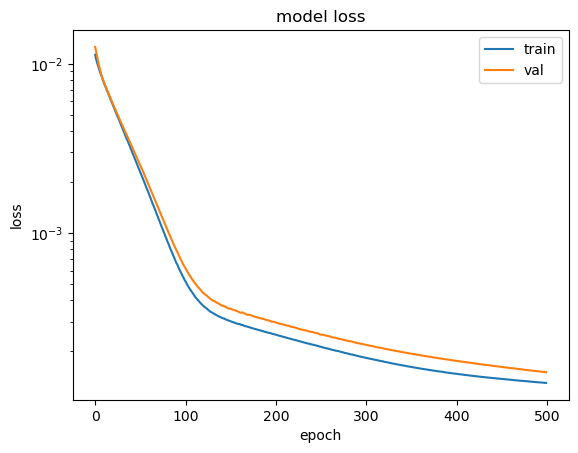

In [53]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Exp Weights:\n", np.exp(weights))
results = np.matmul(test_arr, weights) + biases
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [ ]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=regularizers.l1(1e-6), 
    # activity_regularizer=LogRateL1SumRegularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=10, batch_size=1, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 1600 samples, validate on 400 samples
Epoch 1/10
1600/1600 [==============================] - 2s 1ms/sample - loss: 5.2815e-04 - val_loss: 3.7428e-05
Epoch 2/10
1600/1600 [==============================] - 1s 803us/sample - loss: 2.9254e-05 - val_loss: 2.6757e-05
Epoch 3/10
1600/1600 [==============================] - 1s 837us/sample - loss: 2.6527e-05 - val_loss: 2.5510e-05
Epoch 4/10
1600/1600 [==============================] - 1s 796us/sample - loss: 2.5386e-05 - val_loss: 2.4555e-05
Epoch 5/10
1600/1600 [==============================] - 1s 801us/sample - loss: 2.3941e-05 - val_loss: 2.2616e-05
Epoch 6/10
1600/1600 [==============================] - 1s 809us/sample - loss: 2.1863e-05 - val_loss: 2.3866e-05
Epoch 7/10
1600/1600 [==============================] - 1s 775us/sample - loss: 1.9937e-05 - val_loss: 1.7724e-05
Epoch 8/10
1600/1600 [==============================] - 1s 780us/sample - loss: 1.7930e-05 - val_loss: 1.6144e-05
Epoch 9/10
1600/1600 [=====

Exp Biases: [0.8541684  1.2821438  0.87889165 1.193442   0.8649368  1.186775   0.8871876 ]
Weights:
 [[-3.04377675e-01 -1.12100528e-03  1.55705735e-01  3.41659546e-01  2.49275833e-01  4.45667863e-01  5.16729488e-04]
 [-8.25611353e-02  3.99553716e-01 -4.32514459e-01 -1.45882237e-04 -6.17445782e-02  8.61855894e-02  2.55311048e-03]
 [ 1.87043205e-01 -3.51534247e-01  3.22017670e-01 -1.13365741e-03 -2.93253899e-01  9.14475229e-03  2.65836832e-03]
 [-2.10972607e-01  1.32123493e-02 -5.27938940e-02  5.42730272e-01 -3.22611094e-03 -1.90381089e-03  1.40654563e-03]
 [ 1.35442764e-01 -1.03187142e-03 -2.02225521e-01 -5.60296476e-02  1.82546258e-01  4.86402549e-02  4.75687295e-04]
 [-3.51276815e-01  2.13153303e-01 -2.91729253e-02  1.06410362e-01 -2.91433819e-02 -1.06614409e-03  4.94948763e-04]
 [ 3.64539842e-03 -2.26651937e-01  2.13843718e-01  1.51386529e-01  5.12371004e-01  1.45516515e-01 -1.58006489e-01]
 [-1.12265619e-02  1.91075474e-01 -3.18523087e-02  8.35065320e-02 -3.39648843e-01  2.47725233e

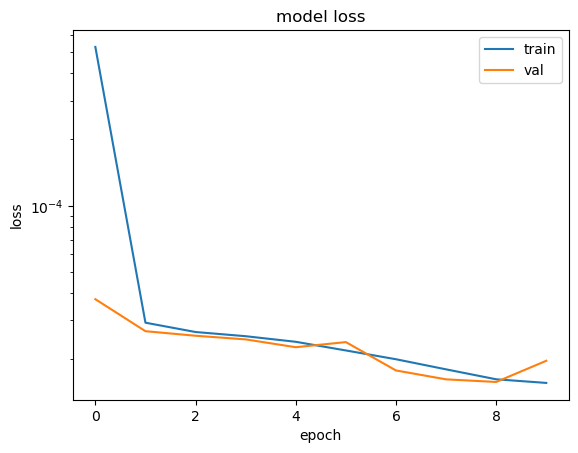

In [78]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
results = np.matmul(test_arr, weights) + biases
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [16]:
# Regularize based on entropy of the rate matrix
class ColumnEntropyRegularizer(Regularizer):
    def __init__(self, coeff=1e-3):
        self.coeff = coeff
    def __call__(self, W):
        P = tf.nn.softmax(W, axis=1)  # normalize rows
        entropy = -tf.reduce_sum(P * tf.math.log(P + 1e-8), axis=1)
        return self.coeff * tf.reduce_mean(entropy)

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=ColumnEntropyRegularizer(1e-5), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=1000, batch_size=16, validation_data=(x_test, y_test)
)


Train on 800 samples, validate on 200 samples
Epoch 1/1000
800/800 [==============================] - 0s 543us/sample - loss: 0.0234 - val_loss: 0.0188
Epoch 2/1000
800/800 [==============================] - 0s 74us/sample - loss: 0.0178 - val_loss: 0.0124
Epoch 3/1000
800/800 [==============================] - 0s 71us/sample - loss: 0.0101 - val_loss: 0.0063
Epoch 4/1000
800/800 [==============================] - 0s 71us/sample - loss: 0.0045 - val_loss: 0.0030
Epoch 5/1000
800/800 [==============================] - 0s 70us/sample - loss: 0.0021 - val_loss: 0.0013
Epoch 6/1000
800/800 [==============================] - 0s 70us/sample - loss: 0.0010 - val_loss: 6.6329e-04
Epoch 7/1000
800/800 [==============================] - 0s 71us/sample - loss: 5.6048e-04 - val_loss: 3.6803e-04
Epoch 8/1000
800/800 [==============================] - 0s 76us/sample - loss: 3.5127e-04 - val_loss: 2.2621e-04
Epoch 9/1000
800/800 [==============================] - 0s 106us/sample - loss: 2.4635e-04 - 

Exp Biases: [1.3012819  0.8065922  1.2214212  1.0706385  0.926939   1.2815183  0.93189704]
Weights:
 [[-0.0845812  -0.07767997 -0.0097422   0.13979907 -0.12816474 -0.0033754   0.74908036]
 [-0.9135152  -0.19456051  0.09215876 -0.04433048  0.4147357  -0.2315329  -0.6018806 ]
 [ 0.29023388  0.5783318   0.11986806 -0.19779468  0.1406975  -0.10501807  0.17161362]
 [-0.53823054  0.5658995   0.53940773 -0.31522524 -0.22030616  0.55216956 -0.261765  ]
 [ 0.16297835 -0.85364383  0.4456619  -0.29680938 -0.15096512  0.48078564 -0.5521372 ]
 [-0.6414571  -1.0619761   0.7677691  -0.6068716  -1.1473777   1.9249895   0.1111941 ]
 [-0.3238244  -0.07458036 -0.2578006   0.2878166   0.10585895  0.0780798   0.506038  ]
 [ 0.62101984  1.2539967  -0.17649963  1.0113693  -0.22217649  0.5297249  -0.33957374]
 [-0.23908049 -0.12083202  0.05686036  0.5650626   0.06478014 -0.23479621  0.01209385]
 [-0.39831623 -0.70367897 -0.77200073  1.3924884   0.18708213  0.04912483 -0.53897226]
 [ 0.32369635 -0.50994915 -0.

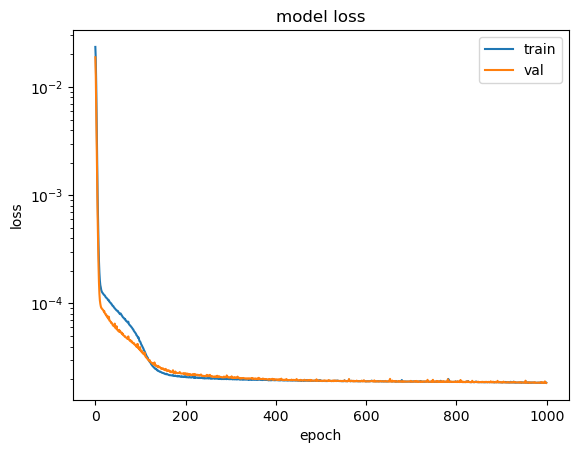

In [17]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * seq_length).reshape(1, seq_length, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Matching Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)
xoff = x.copy()
xoff[:,0]=np.array([0,1])
print("Missmatching Rates:", np.exp(activation.predict(xoff)))
print("Missmatch activity:", model.predict(xoff))

In [ ]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Fri Jul 04 2025

Python implementation: CPython
Python version       : 3.7.3
IPython version      : 7.33.0

numpy     : 1.18.5
scipy     : 1.5.3
matplotlib: 3.5.1
pandas    : 1.3.5
sklearn   : 1.0.2
tensorflow: 1.14.0
seaborn   : 0.12.2

Watermark: 2.5.0

